/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.7225 - loss: 0.6230 - val_accuracy: 0.8901 - val_loss: 0.5094
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9341 - loss: 0.4435 - val_accuracy: 0.9670 - val_loss: 0.3616
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9533 - loss: 0.3029 - val_accuracy: 0.9670 - val_loss: 0.2509
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9670 - loss: 0.2013 - val_accuracy: 0.9670 - val_loss: 0.1753
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9780 - loss: 0.1364 - val_accuracy: 0.9780 - val_loss: 0.1323
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9808 - loss: 0.0984 - val_accuracy: 0.9780 - val_loss: 0.1096
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9835 - loss: 0.0772 - val_accuracy: 0.9780 - val_loss: 0.0983
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9835 - loss: 0.0647 - val_accuracy: 0.9780 - 

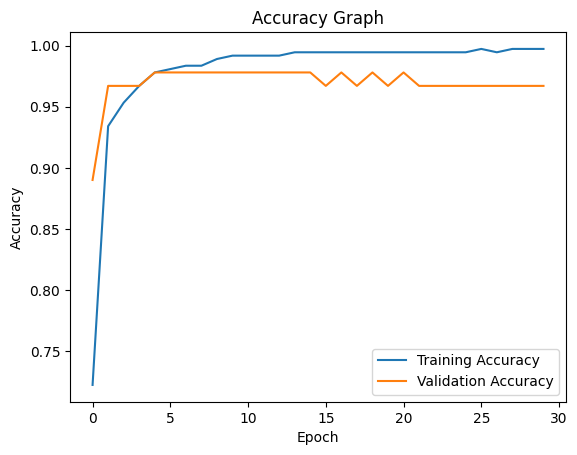

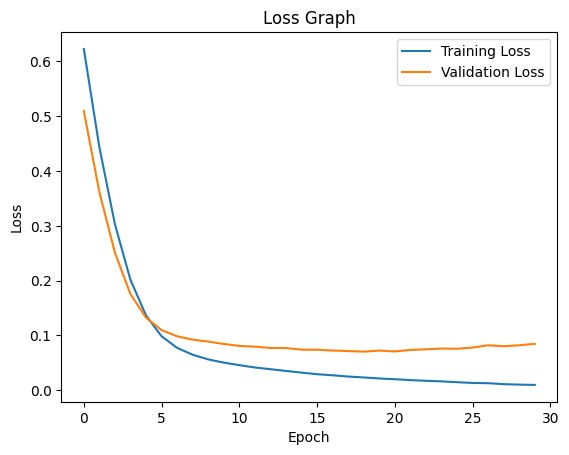


Model trained and tested successfully.
The confusion matrix and accuracy show the classification performance.


In [1]:
# ===========================================
# Deep Feed Forward Network for Classification
# Breast Cancer Dataset
# ===========================================

# Import Libraries
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# -----------------------------
# Load Dataset
# -----------------------------
data = load_breast_cancer()

X = data.data          # Input features
y = data.target        # Target (0 = Malignant, 1 = Benign)

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% testing data
    random_state=42
)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Build Deep Feed Forward Network
# -----------------------------
model = Sequential()

# Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Hidden Layer 3
model.add(Dense(16, activation='relu'))

# Output Layer (Binary Classification)
model.add(Dense(1, activation='sigmoid'))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# Test Model
# -----------------------------
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy :", accuracy)

# -----------------------------
# Predictions
# -----------------------------
predictions = model.predict(X_test)

# Convert probabilities to 0 or 1
predictions = (predictions > 0.5)

# -----------------------------
# Accuracy
# -----------------------------
print("\nAccuracy Score:")
print(accuracy_score(y_test, predictions))

# -----------------------------
# Confusion Matrix
# -----------------------------
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# -----------------------------
# Accuracy Graph
# -----------------------------
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -----------------------------
# Loss Graph
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -----------------------------
# Conclusion
# -----------------------------
print("\nModel trained and tested successfully.")
print("The confusion matrix and accuracy show the classification performance.")